In [1]:
##EDA using bivarite and multivariate
import seaborn as sns
import pandas as pd


In [6]:
tips=sns.load_dataset('tips')

In [7]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
titanic=pd.read_csv("Titanic-Dataset.csv")

In [34]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
flights=sns.load_dataset("flights")


In [8]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [5]:
iris=sns.load_dataset('iris')

In [9]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='total_bill', ylabel='tip'>

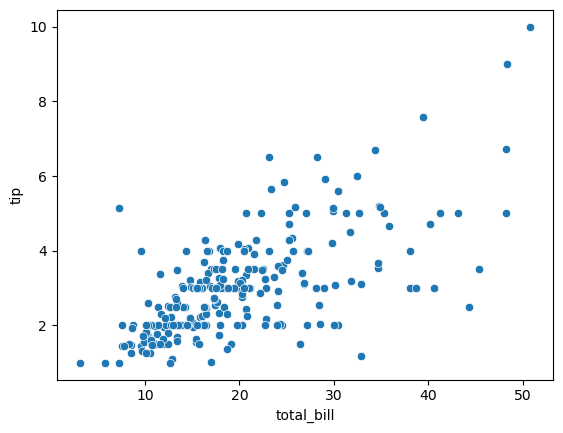

In [12]:
##bivariate analysis
##1 numerical-numerical
##using scatter plot
##bivariate analysis
##1 numerical-numerical
##using scatter plot
sns.scatterplot(x='total_bill', y='tip', data=tips)
# OR alternatively:
# sns.scatterplot(data=tips, x='total_bill', y='tip')

<Axes: xlabel='total_bill', ylabel='tip'>

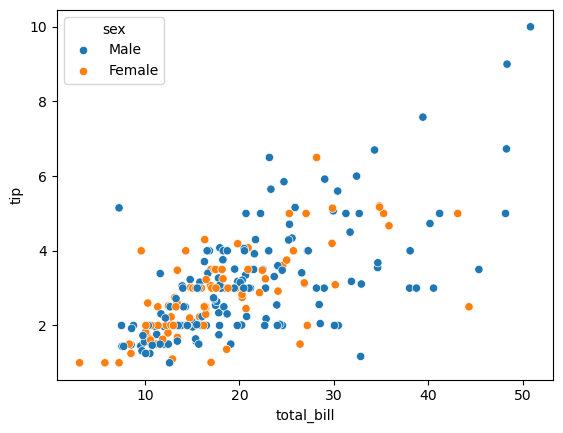

In [13]:
sns.scatterplot(x='total_bill', y='tip', data=tips,hue="sex")

<Axes: xlabel='total_bill', ylabel='tip'>

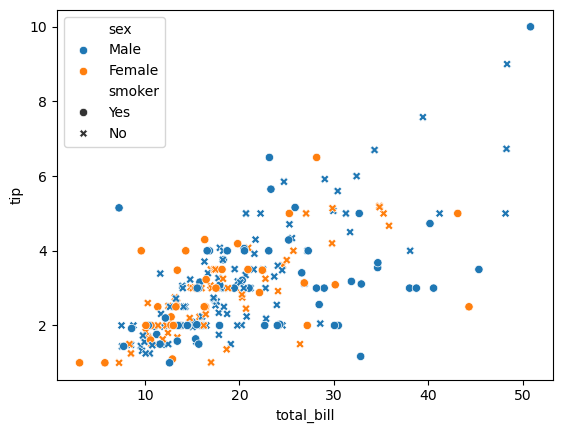

In [14]:
sns.scatterplot(x='total_bill', y='tip', data=tips,hue="sex",style="smoker")

<Axes: xlabel='total_bill', ylabel='tip'>

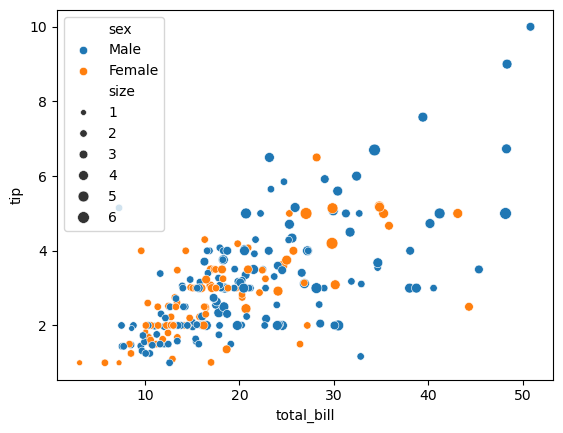

In [15]:
sns.scatterplot(x='total_bill', y='tip', data=tips,hue="sex",size="size")

<Axes: xlabel='Pclass', ylabel='Age'>

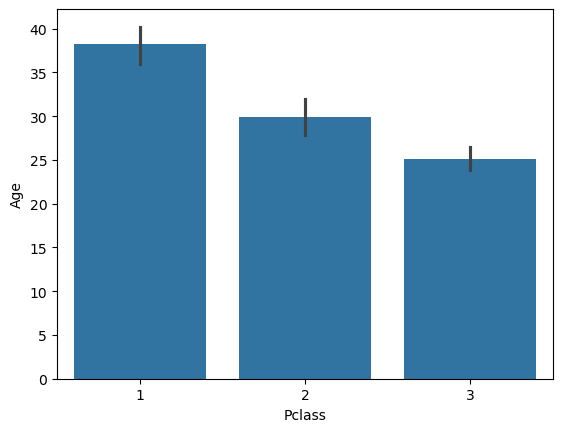

In [17]:
##numerical-categorical
#barplot
sns.barplot(x=titanic["Pclass"], y=titanic["Age"])

<Axes: xlabel='Pclass', ylabel='Fare'>

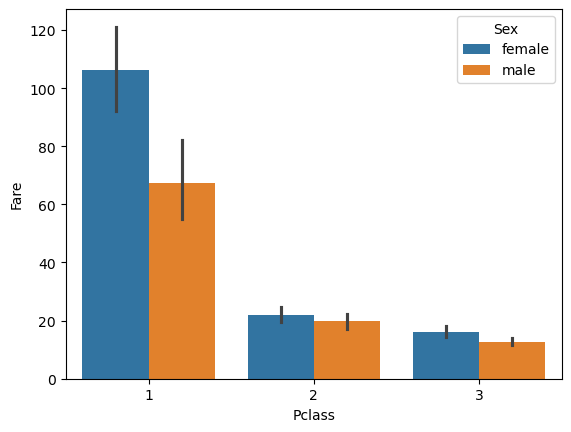

In [19]:
sns.barplot(x=titanic["Pclass"], y=titanic["Fare"],hue=titanic["Sex"])

<Axes: xlabel='Pclass', ylabel='Age'>

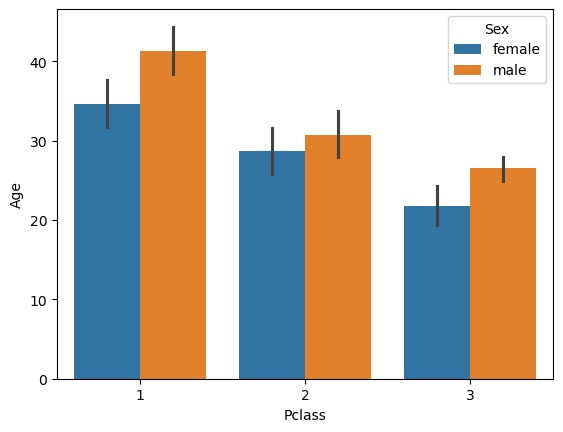

In [20]:
sns.barplot(x=titanic["Pclass"], y=titanic["Age"],hue=titanic["Sex"])

<Axes: xlabel='Sex', ylabel='Age'>

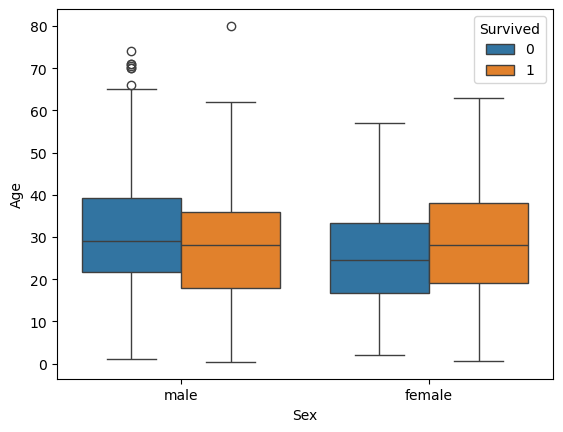

In [23]:
##Box plot
sns.boxplot(x=titanic["Sex"],y=titanic["Age"],hue=titanic["Survived"])

C:\Users\Sejal Jain\AppData\Local\Temp\ipykernel_21524\1154784272.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic[titanic["Survived"]==0]["Age"],hist=False)
C:\Users\Sejal Jain\AppData\Local\Temp\ipykernel_21524\1154784272.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.

<Axes: xlabel='Age', ylabel='Density'>

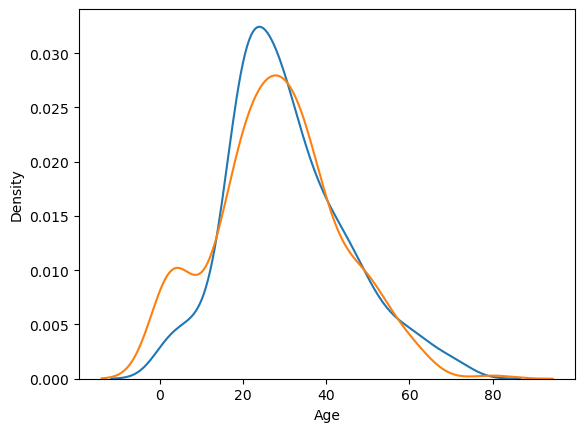

In [25]:
##Displot
sns.distplot(titanic[titanic["Survived"]==0]["Age"],hist=False)
sns.distplot(titanic[titanic["Survived"]==1]["Age"],hist=False)

In [27]:
##heatmap(categorical-categorical)
pd.crosstab(titanic['Pclass'], titanic["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


<Axes: xlabel='Survived', ylabel='Pclass'>

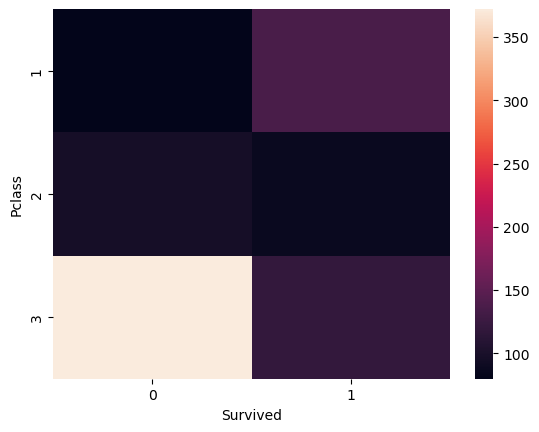

In [28]:
sns.heatmap(pd.crosstab(titanic['Pclass'], titanic["Survived"]))

In [32]:
survival_rate = titanic.groupby("pclass")["survived"].mean() * 100

print(survival_rate)

pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64


In [36]:
survival_rate = titanic.groupby("sex")["survived"].mean() * 100
print(survival_rate)

sex
female    74.203822
male      18.890815
Name: survived, dtype: float64


In [38]:
psurvival_rate = titanic.groupby("embarked")["survived"].mean() * 100
print(survival_rate)

sex
female    74.203822
male      18.890815
Name: survived, dtype: float64


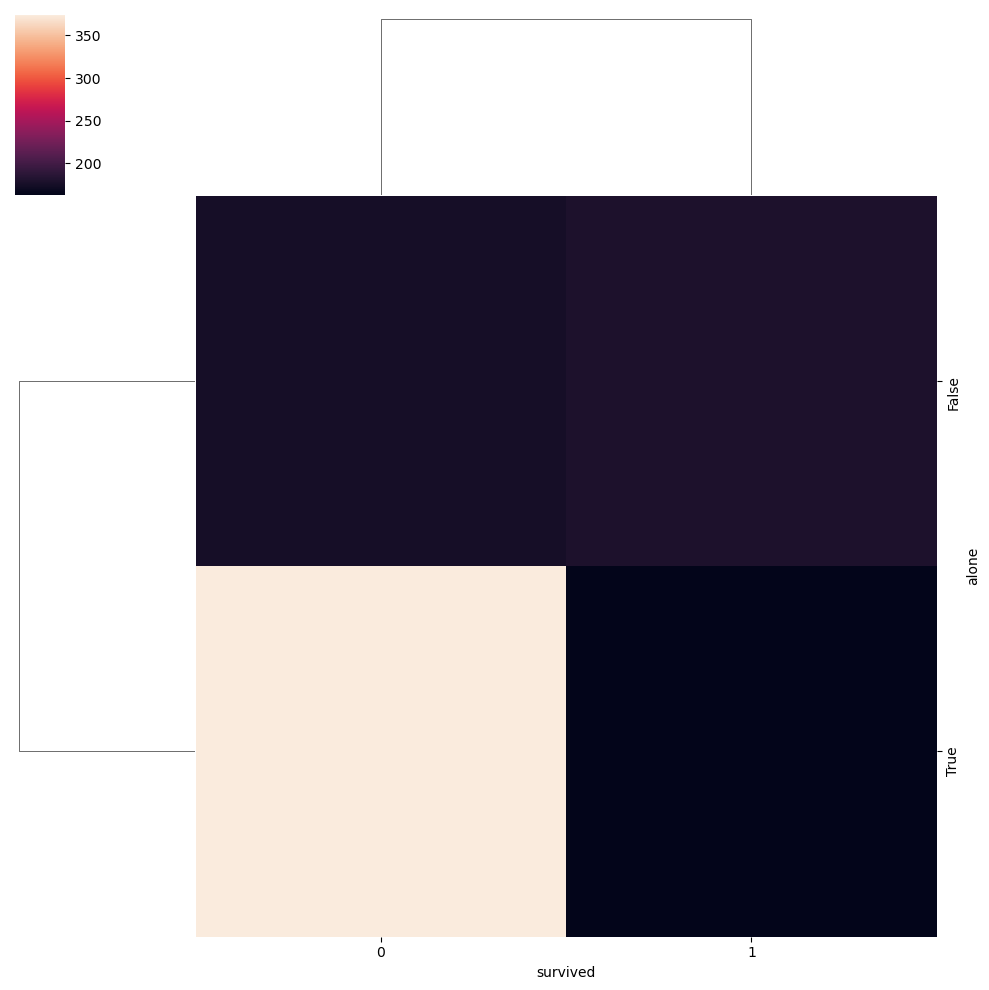

In [39]:
##cluster map
sns.clustermap(pd.crosstab(titanic["alone"],titanic["survived"]))

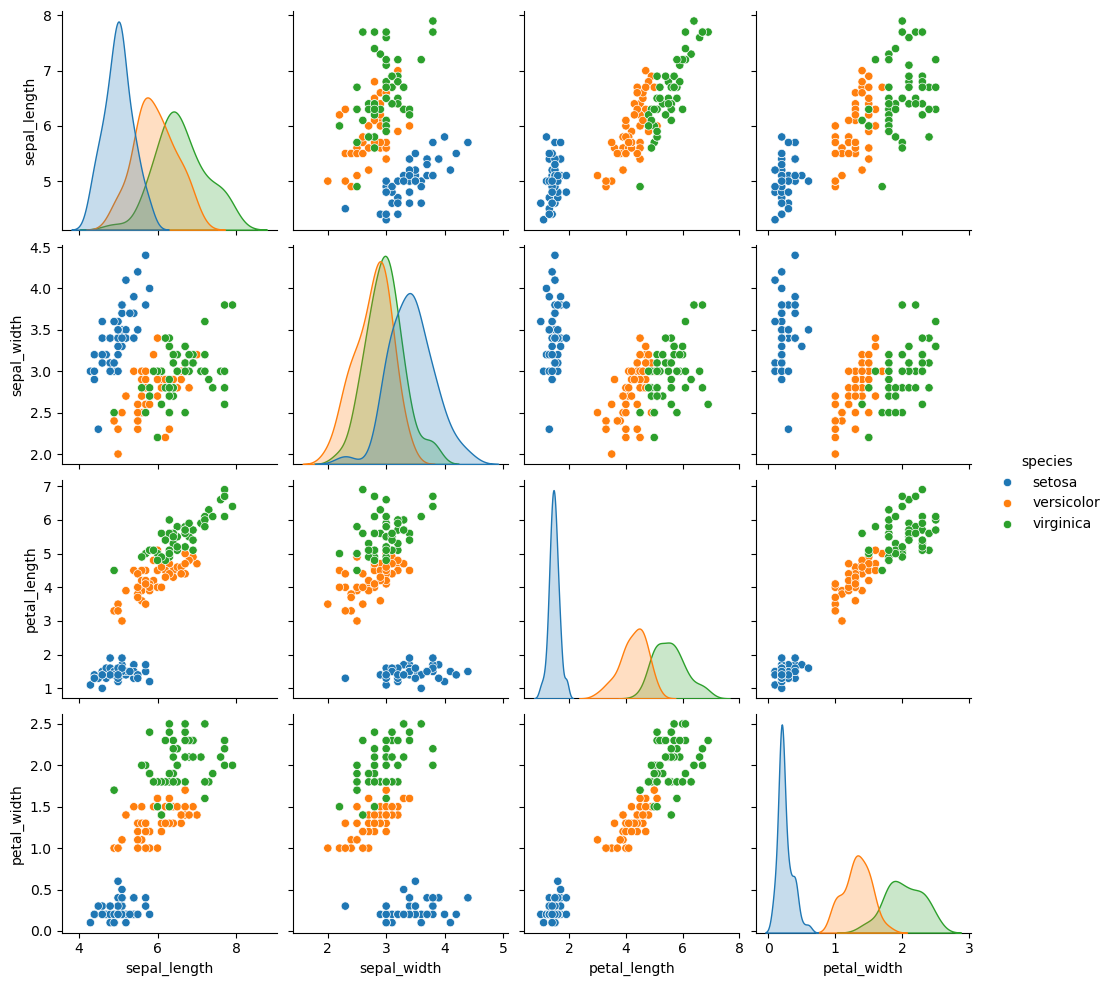

In [41]:
##pairplot
sns.pairplot(iris,hue="species")

In [44]:
##lineplot
##use when time based
# Specify only numeric columns to sum, or exclude categorical columns
# Option 1: Select only numeric columns
numeric_cols = flights.select_dtypes(include=['number']).columns
# Don't reset_index() since 'year' is already a column in the result
flights_grouped = flights.groupby("year")[numeric_cols].sum()
# If you need it as a regular column instead of an index, use:
# flights_grouped = flights.groupby("year")[numeric_cols].sum().reset_index(drop=False)

# Option 2: Alternative approach - exclude the categorical columns explicitly
# flights_grouped = flights.groupby("year").sum(numeric_only=True)

<Axes: xlabel='year', ylabel='passengers'>

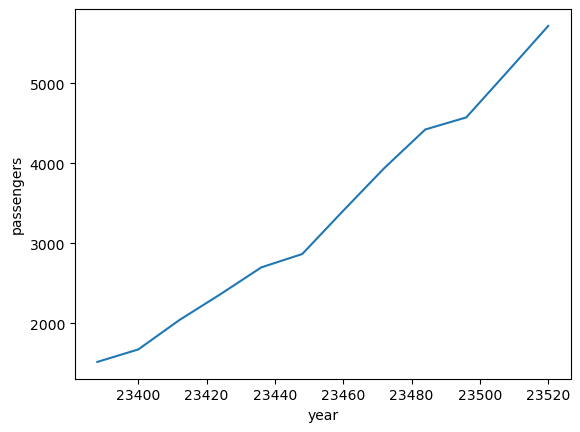

In [46]:
# Corrected code with named parameters
sns.lineplot(x=flights_grouped['year'], y=flights_grouped['passengers'])

# Alternative syntax using data parameter
# sns.lineplot(data=flights_grouped, x='year', y='passengers')

C:\Users\Sejal Jain\AppData\Local\Temp\ipykernel_21524\1868718285.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.clustermap(flights.pivot_table(values='passengers',index='month',columns='year'))


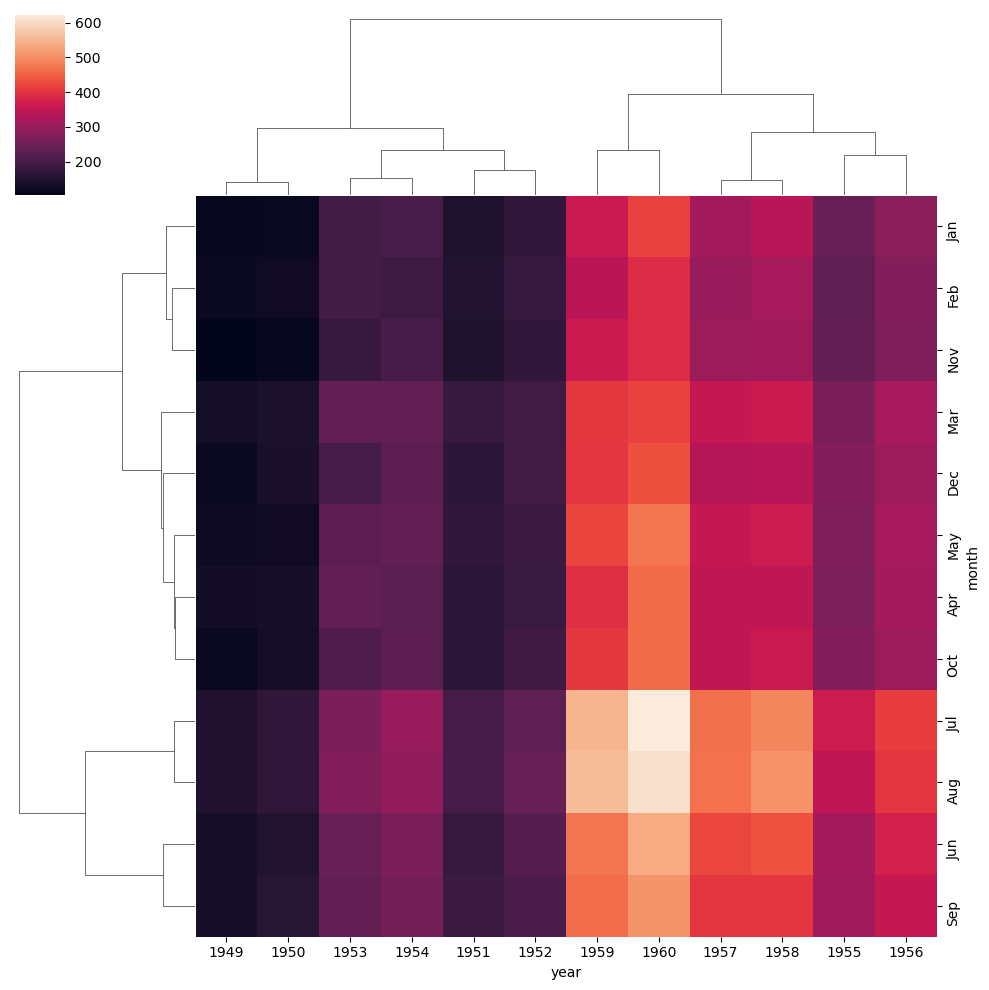

In [47]:
sns.clustermap(flights.pivot_table(values='passengers',index='month',columns='year'))

C:\Users\Sejal Jain\AppData\Local\Temp\ipykernel_21524\2230379170.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.heatmap(flights.pivot_table(values='passengers',index='month',columns='year'))


<Axes: xlabel='year', ylabel='month'>

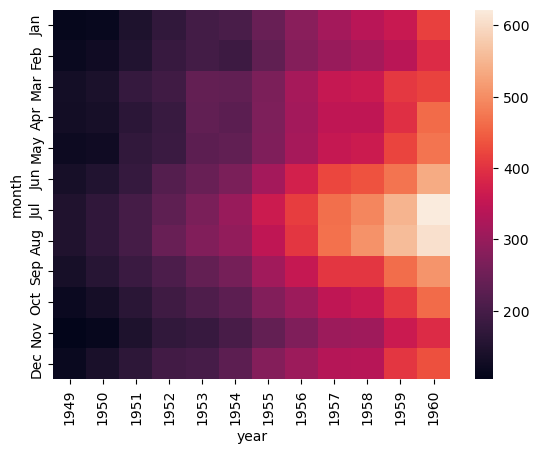

In [48]:
sns.heatmap(flights.pivot_table(values='passengers',index='month',columns='year'))